In [13]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
# Define the path to the CSV file
file_path = r"C:\Users\gunas\OneDrive\Desktop\Prediction_Data.csv"

# Read the CSV file
data = pd.read_csv(file_path)

# Display the first few rows
print(data.head())

   Sum of Age Churn_Category                  Churn_Reason        Contract  \
0          42       Attitude  Attitude of service provider  Month-to-Month   
1          62       Attitude  Attitude of service provider  Month-to-Month   
2          52       Attitude  Attitude of service provider  Month-to-Month   
3          45       Attitude  Attitude of service provider  Month-to-Month   
4          34       Attitude  Attitude of service provider  Month-to-Month   

  Customer_ID Customer_Status Device_Protection_Plan  Gender Internet_Service  \
0   11952-TEL         Churned                    Yes  Female              Yes   
1   12736-ASS         Churned                     No  Female              Yes   
2   12999-BIH         Churned                     No  Female              Yes   
3   13318-AND         Churned                     No    Male              Yes   
4   13829-PUN         Churned                     No  Female              Yes   

  Internet_Type  ... Streaming_Music  Stream

In [14]:
# Drop columns that won't be used for prediction
data = data.drop(['Customer_ID', 'Churn_Category', 'Churn_Reason'], axis=1)

 

# List of columns to be label encoded

columns_to_encode = [

    'Gender', 'Married', 'State', 'Value_Deal', 'Phone_Service', 'Multiple_Lines',

    'Internet_Service', 'Internet_Type', 'Online_Security', 'Online_Backup',

    'Device_Protection_Plan', 'Premium_Support', 'Streaming_TV', 'Streaming_Movies',

    'Streaming_Music', 'Unlimited_Data', 'Contract', 'Paperless_Billing',

    'Payment_Method'

]

 

# Encode categorical variables except the target variable

label_encoders = {}

for column in columns_to_encode:

    label_encoders[column] = LabelEncoder()

    data[column] = label_encoders[column].fit_transform(data[column])

 

# Manually encode the target variable 'Customer_Status'

data['Customer_Status'] = data['Customer_Status'].map({'Stayed': 0, 'Churned': 1})

 

# Split data into features and target

X = data.drop('Customer_Status', axis=1)

y = data['Customer_Status']

 

# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
# Initialize the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

 

# Train the model

rf_model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

Confusion Matrix:
[[773  51]
 [133 245]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.94      0.89       824
           1       0.83      0.65      0.73       378

    accuracy                           0.85      1202
   macro avg       0.84      0.79      0.81      1202
weighted avg       0.85      0.85      0.84      1202



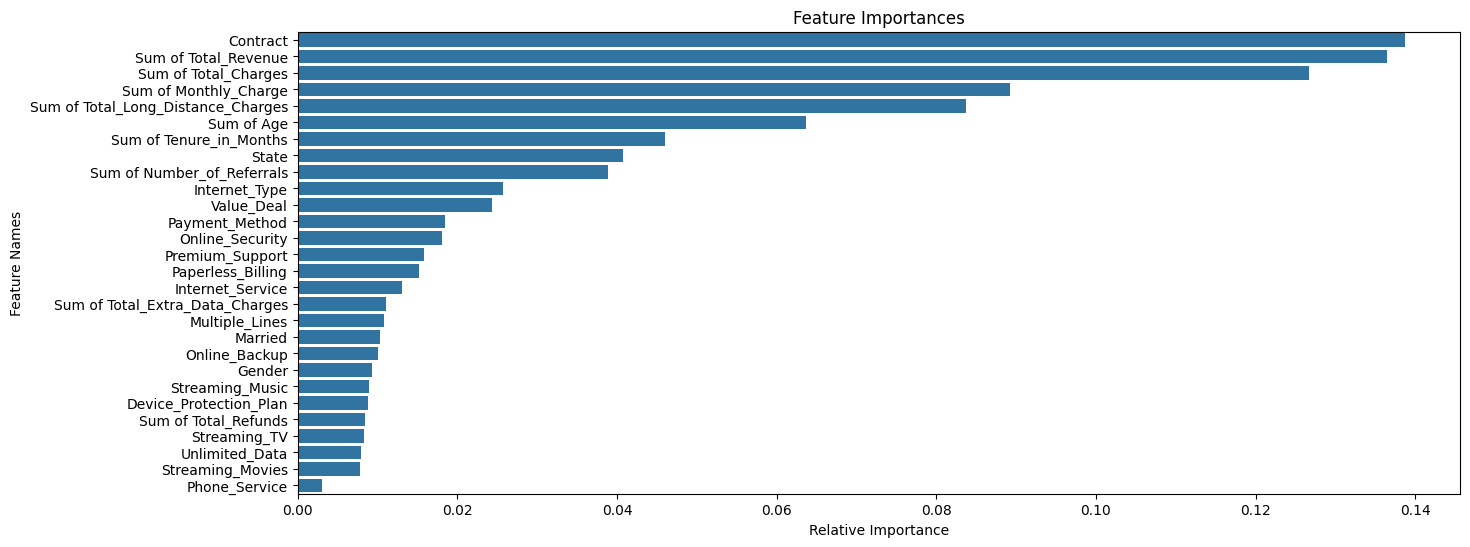

In [30]:
#Evaluate Model

# Make predictions

y_pred = rf_model.predict(X_test)

 

# Evaluate the model

print("Confusion Matrix:")

print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")

print(classification_report(y_test, y_pred))

 

# Feature Selection using Feature Importance

importances = rf_model.feature_importances_

indices = np.argsort(importances)[::-1]

 

# Plot the feature importances

plt.figure(figsize=(15, 6))

sns.barplot(x=importances[indices], y=X.columns[indices])

plt.title('Feature Importances')

plt.xlabel('Relative Importance')

plt.ylabel('Feature Names')

plt.show()

In [48]:
# Define the path to the Joiner Data Excel file
file_path = r"C:\Users\gunas\OneDrive\Desktop\prediction data1.csv"

 

# Define the sheet name to read data from

sheet_name = 'vw_JoinData'

 

# Read the data from the specified sheet into a pandas DataFrame

new_data = pd.read_csv(file_path)

 

# Display the first few rows of the fetched data

print(new_data.head())

 

# Retain the original DataFrame to preserve unencoded columns

original_data = new_data.copy()

 

# Retain the Customer_ID column

customer_ids = new_data['Customer_ID']

 

# Drop columns that won't be used for prediction in the encoded DataFrame

new_data = new_data.drop(['Customer_ID', 'Customer_Status', 'Churn_Category', 'Churn_Reason'], axis=1)

 

# Encode categorical variables using the saved label encoders

for column in new_data.select_dtypes(include=['object']).columns:

    new_data[column] = label_encoders[column].transform(new_data[column])

 

# Make predictions

new_predictions = rf_model.predict(new_data)

 

# Add predictions to the original DataFrame

original_data['Customer_Status_Predicted'] = new_predictions

 

# Filter the DataFrame to include only records predicted as "Churned"

original_data = original_data[original_data['Customer_Status_Predicted'] == 1]

 

# Save the results

original_data.to_csv(
    r"C:\Users\gunas\OneDrive\Desktop\jupyter project\Predictions.csv",
    index=False
)

   Sum of Age Churn_Category Churn_Reason        Contract Customer_ID  \
0          18         Others       Others  Month-to-Month   11751-TAM   
1          27         Others       Others  Month-to-Month   12056-WES   
2          25         Others       Others  Month-to-Month   12136-RAJ   
3          39         Others       Others  Month-to-Month   12257-ASS   
4          51         Others       Others  Month-to-Month   12340-DEL   

  Customer_Status Device_Protection_Plan  Gender Internet_Service  \
0          Joined                     No  Female              Yes   
1          Joined                    Yes    Male              Yes   
2          Joined                     No  Female               No   
3          Joined                     No  Female               No   
4          Joined                     No  Female              Yes   

  Internet_Type  ... Streaming_TV  Sum of Tenure_in_Months  \
0           DSL  ...           No                        7   
1   Fiber Optic  ...  

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- Customer_Status_Predicted


In [52]:
original_data.to_csv("Predictions.csv", index=False)

In [53]:
import os

print(os.listdir())

['.ipynb_checkpoints', 'churn prediction.ipynb', 'Predictions.csv', 'Untitled.ipynb', 'Untitled1.ipynb', 'Untitled2.ipynb']
